# genoselect — tutorial

**scikit-learn-compatible genomic prediction in Python.**

This tutorial fits GBLUP, benchmarks several genomic-prediction models by cross-validation, builds a stacked ensemble, and validates genoselect's GBLUP against the gold-standard R package **rrBLUP**.

## Install

```bash
pip install genoselect
```

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import genoselect as gs

# simulate a population: 250 individuals, 800 SNPs, 40 causal QTL, h2=0.5
pop = gs.simulate_population(n=250, m=800, n_qtl=40, h2=0.5, seed=1)
pop.geno.shape, pop.pheno.shape

((250, 800), (250,))

## Loading your own data

Instead of simulating, read VCF / PLINK / HapMap files in one line:

```python
gd = gs.read_vcf('genotypes.vcf.gz')      # or gs.read_plink('data'), gs.read_hapmap('data.hmp.txt')
fit = gs.GBLUP().fit(gd.geno, phenotypes)
```

## GBLUP: heritability and breeding values

`GBLUP` estimates variance components by REML and returns genomic estimated breeding values (GEBVs).

In [2]:
fit = gs.GBLUP().fit(pop.geno, pop.pheno)
print(f'estimated genomic h2 = {fit.h2_:.3f}')
print(f'GEBV vs true breeding value corr = {np.corrcoef(fit.gebv_, pop.bv)[0,1]:.3f}')

estimated genomic h2 = 0.394
GEBV vs true breeding value corr = 0.739


## Benchmark models by cross-validation

All models share the scikit-learn `fit`/`predict` API. Accuracy is predictive ability — correlation between predicted and observed phenotypes on held-out folds.

In [3]:
cv = gs.cross_validate(pop.geno, pop.pheno,
        models=['gblup', 'elastic_net', 'random_forest', 'gradient_boosting'],
        k=5, random_state=1)
summary = cv.summary()
summary

,model,mean,sd,n_folds
0,elastic_net,0.464567,0.069678,5
1,random_forest,0.374919,0.077158,5
2,gradient_boosting,0.273735,0.159740,5
3,gblup,0.183047,0.106422,5


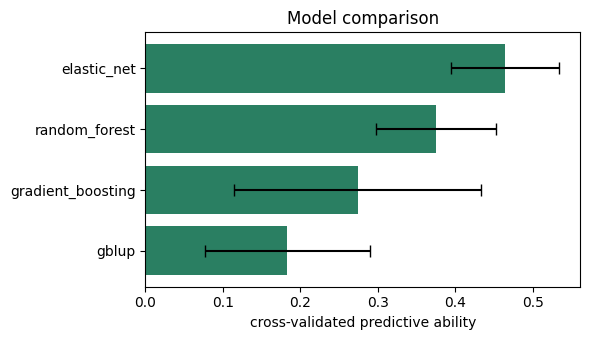

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(summary['model'], summary['mean'], xerr=summary['sd'],
        color='#2a7f62', capsize=4)
ax.set_xlabel('cross-validated predictive ability')
ax.invert_yaxis(); ax.set_title('Model comparison'); fig.tight_layout()
plt.show()

For this **sparse** trait (40 QTL of 800), variable-selection methods such as elastic net beat the infinitesimal GBLUP — a known result that the benchmark recovers automatically.

## Stacked super-learner ensemble

`StackedEnsemble` combines the base models with non-negative weights learned by inner cross-validation.

In [5]:
tr, te = slice(0, 180), slice(180, 250)
ens = gs.StackedEnsemble(random_state=1).fit(pop.geno[tr], pop.pheno[tr])
print('weights:', {k: round(v, 3) for k, v in ens.weights_.items()})
pred = ens.predict(pop.geno[te])
print(f'ensemble pred vs true BV corr = {np.corrcoef(pred, pop.bv[te])[0,1]:.3f}')

weights: {'gblup': np.float64(0.0), 'elastic_net': np.float64(0.512), 'random_forest': np.float64(0.341), 'gradient_boosting': np.float64(0.146)}
ensemble pred vs true BV corr = 0.471


## Validation against rrBLUP

genoselect's GBLUP uses the same REML (Endelman, 2011) spectral method as the reference R package **rrBLUP**. Running both on identical data (200 individuals, 1000 markers) gives essentially identical results:

| metric | result |
|---|---|
| genomic heritability h2 (genoselect / rrBLUP) | 0.3538 / 0.3538 |
| GEBV correlation (genoselect vs rrBLUP) | **1.00000000** |
| max absolute GEBV difference | 6.7e-6 |
| fit time (genoselect / rrBLUP) | **0.04 s** / 0.18 s |

The two implementations agree to ~1e-6 (well below numerical noise), confirming genoselect is a faithful, correct GBLUP — and it runs faster.

Reproduce the rrBLUP side in R:

```r
library(rrBLUP)
A   <- A.mat(geno - 1)          # geno coded 0/1/2
sol <- mixed.solve(y, K = A)    # sol$u = GEBVs; sol$Vu, sol$Ve
```

## Summary

- `GBLUP` — REML, validated against rrBLUP to ~1e-6
- A common scikit-learn interface to GBLUP + ML models + a super-learner
- Honest, breeding-relevant cross-validation
- One-line readers for VCF / PLINK / HapMap

See the [API reference](api.md) and the [GitHub repository](https://github.com/mqfarooqi1/genoselect).